## Supplier Billing Spike and Drop Analysis

### Research Question
Which Missouri providers show abnormal billing spikes followed by a complete drop in services the following year?

### Fraud Signal
A common fraud signal is when a provider rapidly increases billing volume and then disappears from the dataset the following year.

To detect this pattern, we compute:

- Growth from 2021 to 2022
- Drop from 2022 to 2023

We then filter providers where:

2021 services = 0 and
2023 services = 0

This highlights providers that may have exploited billing opportunities temporarily before stopping activity.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

df = pd.read_csv("/dsa/groups/casestudycf25/team02/silver/dmepos_rfrhpr_labeled.csv")

# Missouri suppliers
df_mo = df[df["rfrg_prvdr_state_abrvtn"] == "MO"]

# Aggregate services
provider_year = (
    df_mo
    .groupby(["npi","year"])["tot_suplr_srvcs"]
    .sum()
    .reset_index()
)

# Pivot
pivot = provider_year.pivot(index="npi", columns="year", values="tot_suplr_srvcs").fillna(0)

pivot.head()

/tmp/ipykernel_551/2980036402.py:5: DtypeWarning: Columns (10,11) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv("/dsa/groups/casestudycf25/team02/silver/dmepos_rfrhpr_labeled.csv")


year,2021,2022,2023
npi,,,
1003018201,462.0,0.0,24.0
1003019423,0.0,35.0,37.0
1003036997,0.0,0.0,16.0
1003041625,2102.0,0.0,0.0
1003103490,2792.0,430.0,163.0


In [2]:
pivot["Total"] = pivot[2021] + pivot[2022] + pivot[2023]
pivot.head()

year,2021,2022,2023,Total
npi,,,,
1003018201,462.0,0.0,24.0,486.0
1003019423,0.0,35.0,37.0,72.0
1003036997,0.0,0.0,16.0,16.0
1003041625,2102.0,0.0,0.0,2102.0
1003103490,2792.0,430.0,163.0,3385.0


In [3]:
fraud_pattern = pivot[
    (pivot[2021] == 0) &
    (pivot[2023] == 0) 
]
print(fraud_pattern.shape)
fraud_pattern.head()

(514, 4)


year,2021,2022,2023,Total
npi,,,,
1003432642,0.0,44.0,0.0,44.0
1003929068,0.0,46.0,0.0,46.0
1013198902,0.0,18.0,0.0,18.0
1013322080,0.0,24.0,0.0,24.0
1013424530,0.0,16.0,0.0,16.0


In [4]:
# Create an explicit copy to break the link to the original slice
fraud_pattern = fraud_pattern.copy()


fraud_pattern["growth_21_22"] = fraud_pattern[2022] - fraud_pattern[2021] 
fraud_pattern["drop_22_23"] = fraud_pattern[2022] - fraud_pattern[2023]


fraud_pattern.head()

year,2021,2022,2023,Total,growth_21_22,drop_22_23
npi,,,,,,
1003432642,0.0,44.0,0.0,44.0,44.0,44.0
1003929068,0.0,46.0,0.0,46.0,46.0,46.0
1013198902,0.0,18.0,0.0,18.0,18.0,18.0
1013322080,0.0,24.0,0.0,24.0,24.0,24.0
1013424530,0.0,16.0,0.0,16.0,16.0,16.0


In [7]:
#We need to store the sum of all provider spend and also the count of the number of surges providers
pro_count = pd.DataFrame({
    'Total_Spend': [pivot["Total"].sum()],
    'Surge_Supplier_Count': [fraud_pattern.shape[0]]
})

In [8]:
pro_count

,Total_Spend,Surge_Supplier_Count
0,187412298.0,514


In [9]:
pro_count.to_csv("provider_surges_count.csv")
print("Saved: provider_surges_count.csv")

Saved: provider_surges_count.csv


In [10]:
fraud_pattern = fraud_pattern.sort_values(
    "growth_21_22", ascending=False
)
all_pattern = fraud_pattern
fraud_pattern = fraud_pattern.head()

In [11]:
plot_df = fraud_pattern.reset_index()[
    ["npi","growth_21_22","drop_22_23"]
]

plot_df

year,npi,growth_21_22,drop_22_23
0,1164460762,47264.0,47264.0
1,1366899841,9880.0,9880.0
2,1730329640,9789.0,9789.0
3,1326020082,9755.0,9755.0
4,1336401942,8142.0,8142.0


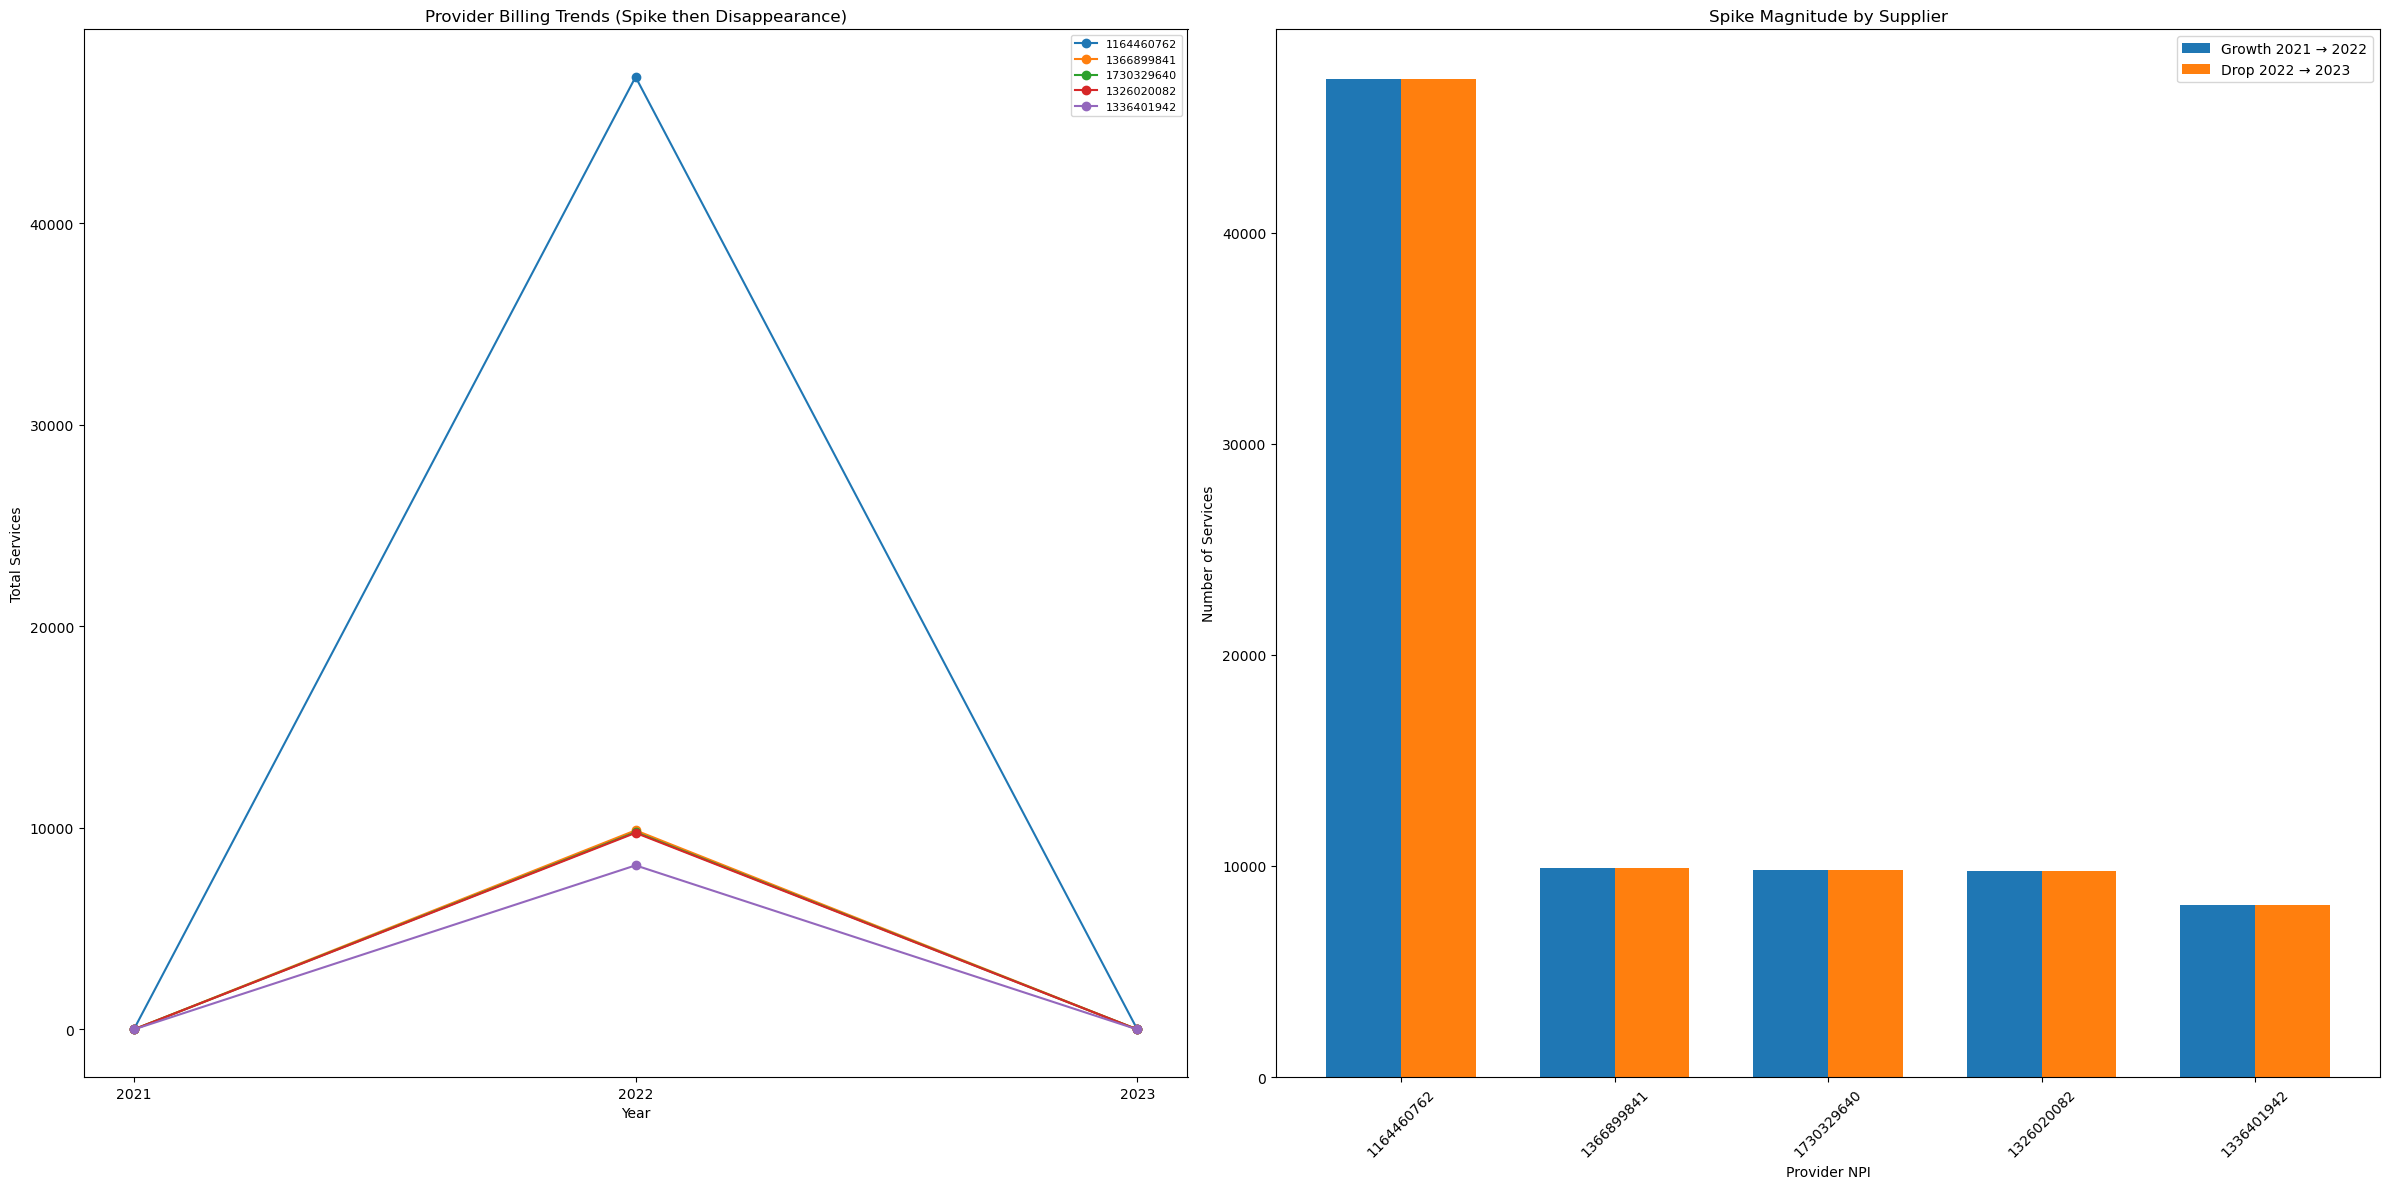

In [15]:
# Top suppliers used in the visualization
top_providers = fraud_pattern.head()

# NPIs for the line plot
top_npis = top_providers.index.tolist()

# Convert pivot table back to long format for line plot
trend_df = pivot.loc[top_npis].reset_index().melt(
    id_vars="npi",
    value_vars=[2021, 2022, 2023],
    var_name="year",
    value_name="tot_suplr_srvcs"
)

fig, axes = plt.subplots(1, 2, figsize=(24, 12))

# -------------------------
# LINE PLOT (Supplier Trend)
# -------------------------
for npi in top_npis:

    data = trend_df[trend_df["npi"] == npi]

    axes[0].plot(
        data["year"],
        data["tot_suplr_srvcs"],
        marker="o",
        label=str(npi)
    )

axes[0].set_xticks([2021, 2022, 2023])
axes[0].set_title("Provider Billing Trends (Spike then Disappearance)")
axes[0].set_xlabel("Year")
axes[0].set_ylabel("Total Services")
axes[0].legend(fontsize=8)


# -------------------------
# BAR PLOT (Spike Magnitude)
# -------------------------
plot_df = top_providers.reset_index()

x = np.arange(len(plot_df))
width = 0.35

axes[1].bar(
    x - width/2,
    plot_df["growth_21_22"],
    width,
    label="Growth 2021 → 2022"
)

axes[1].bar(
    x + width/2,
    plot_df["drop_22_23"],
    width,
    label="Drop 2022 → 2023"
)

axes[1].set_xticks(x)
axes[1].set_xticklabels(plot_df["npi"], rotation=45)

axes[1].set_title("Spike Magnitude by Supplier")
axes[1].set_xlabel("Provider NPI")
axes[1].set_ylabel("Number of Services")

axes[1].legend()

plt.tight_layout()
plt.show()

### HCPCS Code Concentration Analysis

After identifying providers with a spike-and-disappearance pattern, we examine
which HCPCS codes they billed during the spike year (2022).

This helps determine whether the flagged suppliers concentrate their activity
around a small number of service codes.

If multiple flagged providers are billing the same HCPCS code, that code may
represent a higher fraud risk and should be monitored more closely.

In [16]:
flagged_npis = top_providers.index.tolist()

print(flagged_npis)

[1164460762, 1366899841, 1730329640, 1326020082, 1336401942]


In [17]:
spike_df = df_mo[
    (df_mo["npi"].isin(flagged_npis)) &
    (df_mo["year"] == 2022)
]

In [19]:
# Set max colwidth to None to show the full description
pd.set_option('display.max_colwidth', None)

hcpcs_usage = (
    spike_df
    .groupby(["hcpcs_cd", "hcpcs_desc"])["tot_suplr_srvcs"]
    .sum()
    .reset_index()
    .sort_values("tot_suplr_srvcs", ascending=False)
)

hcpcs_usage

,hcpcs_cd,hcpcs_desc,tot_suplr_srvcs
7,J0133,"Injection, acyclovir, 5 mg",46971
5,B4152,"Enteral formula, nutritionally complete, calorically dense (equal to or greater than 1.5 kcal/ml) with intact nutrients, includes proteins, fats, carbohydrates, vitamins and minerals, may include fiber, administered through an enteral feeding tube, 100 calories = 1 unit",28068
4,B4150,"Enteral formula, nutritionally complete with intact nutrients, includes proteins, fats, carbohydrates, vitamins and minerals, may include fiber, administered through an enteral feeding tube, 100 calories = 1 unit",8142
2,B4034,"Enteral feeding supply kit; syringe fed, per day, includes but not limited to feeding/flushing syringe, administration set tubing, dressings, tape",947
3,B4036,"Enteral feeding supply kit; gravity fed, per day, includes but not limited to feeding/flushing syringe, administration set tubing, dressings, tape",396
1,A4222,"Infusion supplies for external drug infusion pump, per cassette or bag (list drugs separately)",279
0,A4221,"Supplies for maintenance of non-insulin drug infusion catheter, per week (list drugs separately)",14
6,E0776,Iv pole,13


Which codes these suspicious providers used the most

In [21]:
provider_hcpcs = (
    spike_df
    .groupby(["npi", "rfrg_prvdr_last_name_org", "rfrg_prvdr_first_name", "hcpcs_cd", "hcpcs_desc"])["tot_suplr_srvcs"]
    .sum()
    .reset_index()
    .sort_values("npi", ascending=True)
)

provider_hcpcs.head(20)

,npi,rfrg_prvdr_last_name_org,rfrg_prvdr_first_name,hcpcs_cd,hcpcs_desc,tot_suplr_srvcs
0,1164460762,Esguerra,Eden,A4221,"Supplies for maintenance of non-insulin drug infusion catheter, per week (list drugs separately)",14
1,1164460762,Esguerra,Eden,A4222,"Infusion supplies for external drug infusion pump, per cassette or bag (list drugs separately)",279
2,1164460762,Esguerra,Eden,J0133,"Injection, acyclovir, 5 mg",46971
3,1326020082,Byrne,Kevin,B4034,"Enteral feeding supply kit; syringe fed, per day, includes but not limited to feeding/flushing syringe, administration set tubing, dressings, tape",637
4,1326020082,Byrne,Kevin,B4152,"Enteral formula, nutritionally complete, calorically dense (equal to or greater than 1.5 kcal/ml) with intact nutrients, includes proteins, fats, carbohydrates, vitamins and minerals, may include fiber, administered through an enteral feeding tube, 100 calories = 1 unit",9118
5,1336401942,Patel,Mitesh,B4150,"Enteral formula, nutritionally complete with intact nutrients, includes proteins, fats, carbohydrates, vitamins and minerals, may include fiber, administered through an enteral feeding tube, 100 calories = 1 unit",8142
6,1366899841,Brenneman,Randall,B4036,"Enteral feeding supply kit; gravity fed, per day, includes but not limited to feeding/flushing syringe, administration set tubing, dressings, tape",396
7,1366899841,Brenneman,Randall,B4152,"Enteral formula, nutritionally complete, calorically dense (equal to or greater than 1.5 kcal/ml) with intact nutrients, includes proteins, fats, carbohydrates, vitamins and minerals, may include fiber, administered through an enteral feeding tube, 100 calories = 1 unit",9471
8,1366899841,Brenneman,Randall,E0776,Iv pole,13
9,1730329640,Ledl,Stephanie,B4034,"Enteral feeding supply kit; syringe fed, per day, includes but not limited to feeding/flushing syringe, administration set tubing, dressings, tape",310


In [27]:
srvc_tot = provider_hcpcs.tot_suplr_srvcs.sum()
print(f'{srvc_tot} total services')

84830 total services


### Top Services for Flagged Providers

* **Eden Esguerra**: Injection, acyclovir, 5 mg (**46,971 services**)
* **Stephanie Ledl**: Enteral formula, nutritionally complete, calorically dense (equal to or greater than 1.5 kcal/ml) with intact nutrients, includes proteins, fats, carbohydrates, vitamins and minerals, may include fiber, administered through an enteral feeding tube, 100 calories = 1 unit (**9,479 services**)
* **Randall Brenneman**: Enteral formula, nutritionally complete, calorically dense (equal to or greater than 1.5 kcal/ml) with intact nutrients, includes proteins, fats, carbohydrates, vitamins and minerals, may include fiber, administered through an enteral feeding tube, 100 calories = 1 unit (**9,471 services**)

**Note:** The most frequently used HCPCS code is **B4152** (Enteral formula, nutritionally complete, calorically dense (equal to or greater than 1.5 kcal/ml) with intact nutrients, includes proteins, fats, carbohydrates, vitamins and minerals, may include fiber, administered through an enteral feeding tube, 100 calories = 1 unit) with **28,068 total services**.

In [23]:
hcpcs_provider_counts = (
    provider_hcpcs
    .groupby("hcpcs_cd")["npi"]
    .nunique()
    .reset_index(name="provider_count")
    .sort_values("provider_count", ascending=False)
)

hcpcs_provider_counts.head(10)

,hcpcs_cd,provider_count
5,B4152,3
2,B4034,2
0,A4221,1
1,A4222,1
3,B4036,1
4,B4150,1
6,E0776,1
7,J0133,1


HCPCS code used by multiple spike providers

In [24]:
heatmap_df = spike_df.pivot_table(
    index="npi",
    columns="hcpcs_cd",
    values="tot_suplr_srvcs",
    aggfunc="sum",
    fill_value=0
)

heatmap_df

hcpcs_cd,A4221,A4222,B4034,B4036,B4150,B4152,E0776,J0133
npi,,,,,,,,
1164460762,14,279,0,0,0,0,0,46971
1326020082,0,0,637,0,0,9118,0,0
1336401942,0,0,0,0,8142,0,0,0
1366899841,0,0,0,396,0,9471,13,0
1730329640,0,0,310,0,0,9479,0,0


### **Anomalous Activity: Top Medical Center LP (NPI: 1215504394)**

The heatmap reveals that **NPI 1164460762** accounts for a disproportionate volume of services. This concentration is a potential fraud indicator, particularly if the billing patterns deviate from the provider's documented specialty.

**Key Billed Services:**
*   **A4221**: Supplies for maintenance of non-insulin drug infusion catheter, per week (list drugs separately).
*   **A4222**: Infusion supplies for external drug infusion pump, per cassette or bag (list drugs separately).
*   **J0133**: Injection, acyclovir, 5 mg.

**Risk Assessment:** The high frequency of acyclovir injections (J0133) from a single provider warrants a manual audit of specialty credentials.


In [26]:
pd.set_option('display.max_columns', None)
spike_df[spike_df.npi==1164460762]
# item aligns with the provider's specialty but the number of services is very high for a signle provider

,npi,rfrg_prvdr_last_name_org,rfrg_prvdr_first_name,rfrg_prvdr_mi,rfrg_prvdr_crdntls,rfrg_prvdr_ent_cd,rfrg_prvdr_st1,rfrg_prvdr_st2,rfrg_prvdr_city,rfrg_prvdr_state_abrvtn,rfrg_prvdr_state_fips,rfrg_prvdr_zip5,rfrg_prvdr_ruca_cat,rfrg_prvdr_ruca,rfrg_prvdr_ruca_desc,rfrg_prvdr_cntry,rfrg_prvdr_spclty_cd,rfrg_prvdr_spclty_desc,rfrg_prvdr_spclty_srce,rbcs_lvl,rbcs_id,rbcs_desc,hcpcs_cd,hcpcs_desc,suplr_rentl_ind,tot_suplrs,tot_suplr_benes,tot_suplr_clms,tot_suplr_srvcs,avg_suplr_sbmtd_chrg,avg_suplr_mdcr_alowd_amt,avg_suplr_mdcr_pymt_amt,avg_suplr_mdcr_stdzd_amt,year,aapc_desc,tot_suplr_mdcr_pymt_amt,tot_suplr_mdcr_pymt_amt_hcpcs_rentl_ind_z_scr,avg_suplr_mdcr_alowd_amt_hcpcs_rentl_ind_rat,target
1753363,1164460762,Esguerra,Eden,M,md,I,100 Mercy Way,Suite 470,Joplin,MO,29,64804,Urban,1.0,"Metropolitan area core: primary flow within an urbanized area of 50,000 and greater",US,44,infectious_disease,Claim-Specialty,Durable Medical Equipment,DE017N,DME-Other DME,A4221,"Supplies for maintenance of non-insulin drug infusion catheter, per week (list drugs separately)",N,1,5.0,14,14,1258.120000,24.77000,19.605714,18.280000,2022,Injection and Infusion Supplies,274.48,-0.468730,1.060661,0
1753364,1164460762,Esguerra,Eden,M,md,I,100 Mercy Way,Suite 470,Joplin,MO,29,64804,Urban,1.0,"Metropolitan area core: primary flow within an urbanized area of 50,000 and greater",US,44,infectious_disease,Claim-Specialty,Durable Medical Equipment,DA000N,DME-Medical/Surgical Supplies,A4222,"Infusion supplies for external drug infusion pump, per cassette or bag (list drugs separately)",N,1,5.0,14,279,598.294839,49.31000,39.023943,35.578100,2022,Injection and Infusion Supplies,10887.68,0.162324,1.100826,0
1753365,1164460762,Esguerra,Eden,M,md,I,100 Mercy Way,Suite 470,Joplin,MO,29,64804,Urban,1.0,"Metropolitan area core: primary flow within an urbanized area of 50,000 and greater",US,44,infectious_disease,Claim-Specialty,Unknown,RI000N,Treatment-Injections and Infusions (nononcologic),J0133,"Injection, acyclovir, 5 mg",N,1,5.0,14,46971,1.257759,0.03587,0.028411,0.028117,2022,"Drugs, Administered by Injection",1334.50,-0.707107,0.981957,0


### Final Insight: Targeted Fraud Detection through Multi-Layered Analysis

This analysis bridges provider-level anomalies with specific service-level patterns to pinpoint high-risk activity. We identified **514 providers** with high fraud potential by isolating Missouri providers that met the following "spike-and-disappearance" criteria:

*   **2021:** Zero services (Inactive)
*   **2022:** Significant billing surge (Active Spike)
*   **2023:** Total drop-off in services (Disappeared)

**Key Findings:**
*   **Concentrated Service Billing:** Flagged providers concentrated 2022 activity around a small number of HCPCS codes, suggesting specialized exploitation rather than broad medical service.
*   **High-Volume Outliers:** One specific provider—**Eden Esguerra** (J0133: 46,971 services)—accounted for the majority of suspicious volume.
*   **Shared Risk Indicators:** HCPCS code **B4152 (Enteral formula, nutritionally complete, calorically dense (equal to or greater than 1.5 kcal/ml) with intact nutrients, includes proteins, fats, carbohydrates, vitamins and minerals, may include fiber, administered through an enteral feeding tube, 100 calories = 1 unit)** was billed by multiple "spike" providers, marking it as a high-risk service category for ongoing monitoring.

This data-driven approach demonstrates how connecting provider-level anomalies to service-level patterns transforms raw CMS data into actionable investigative leads.


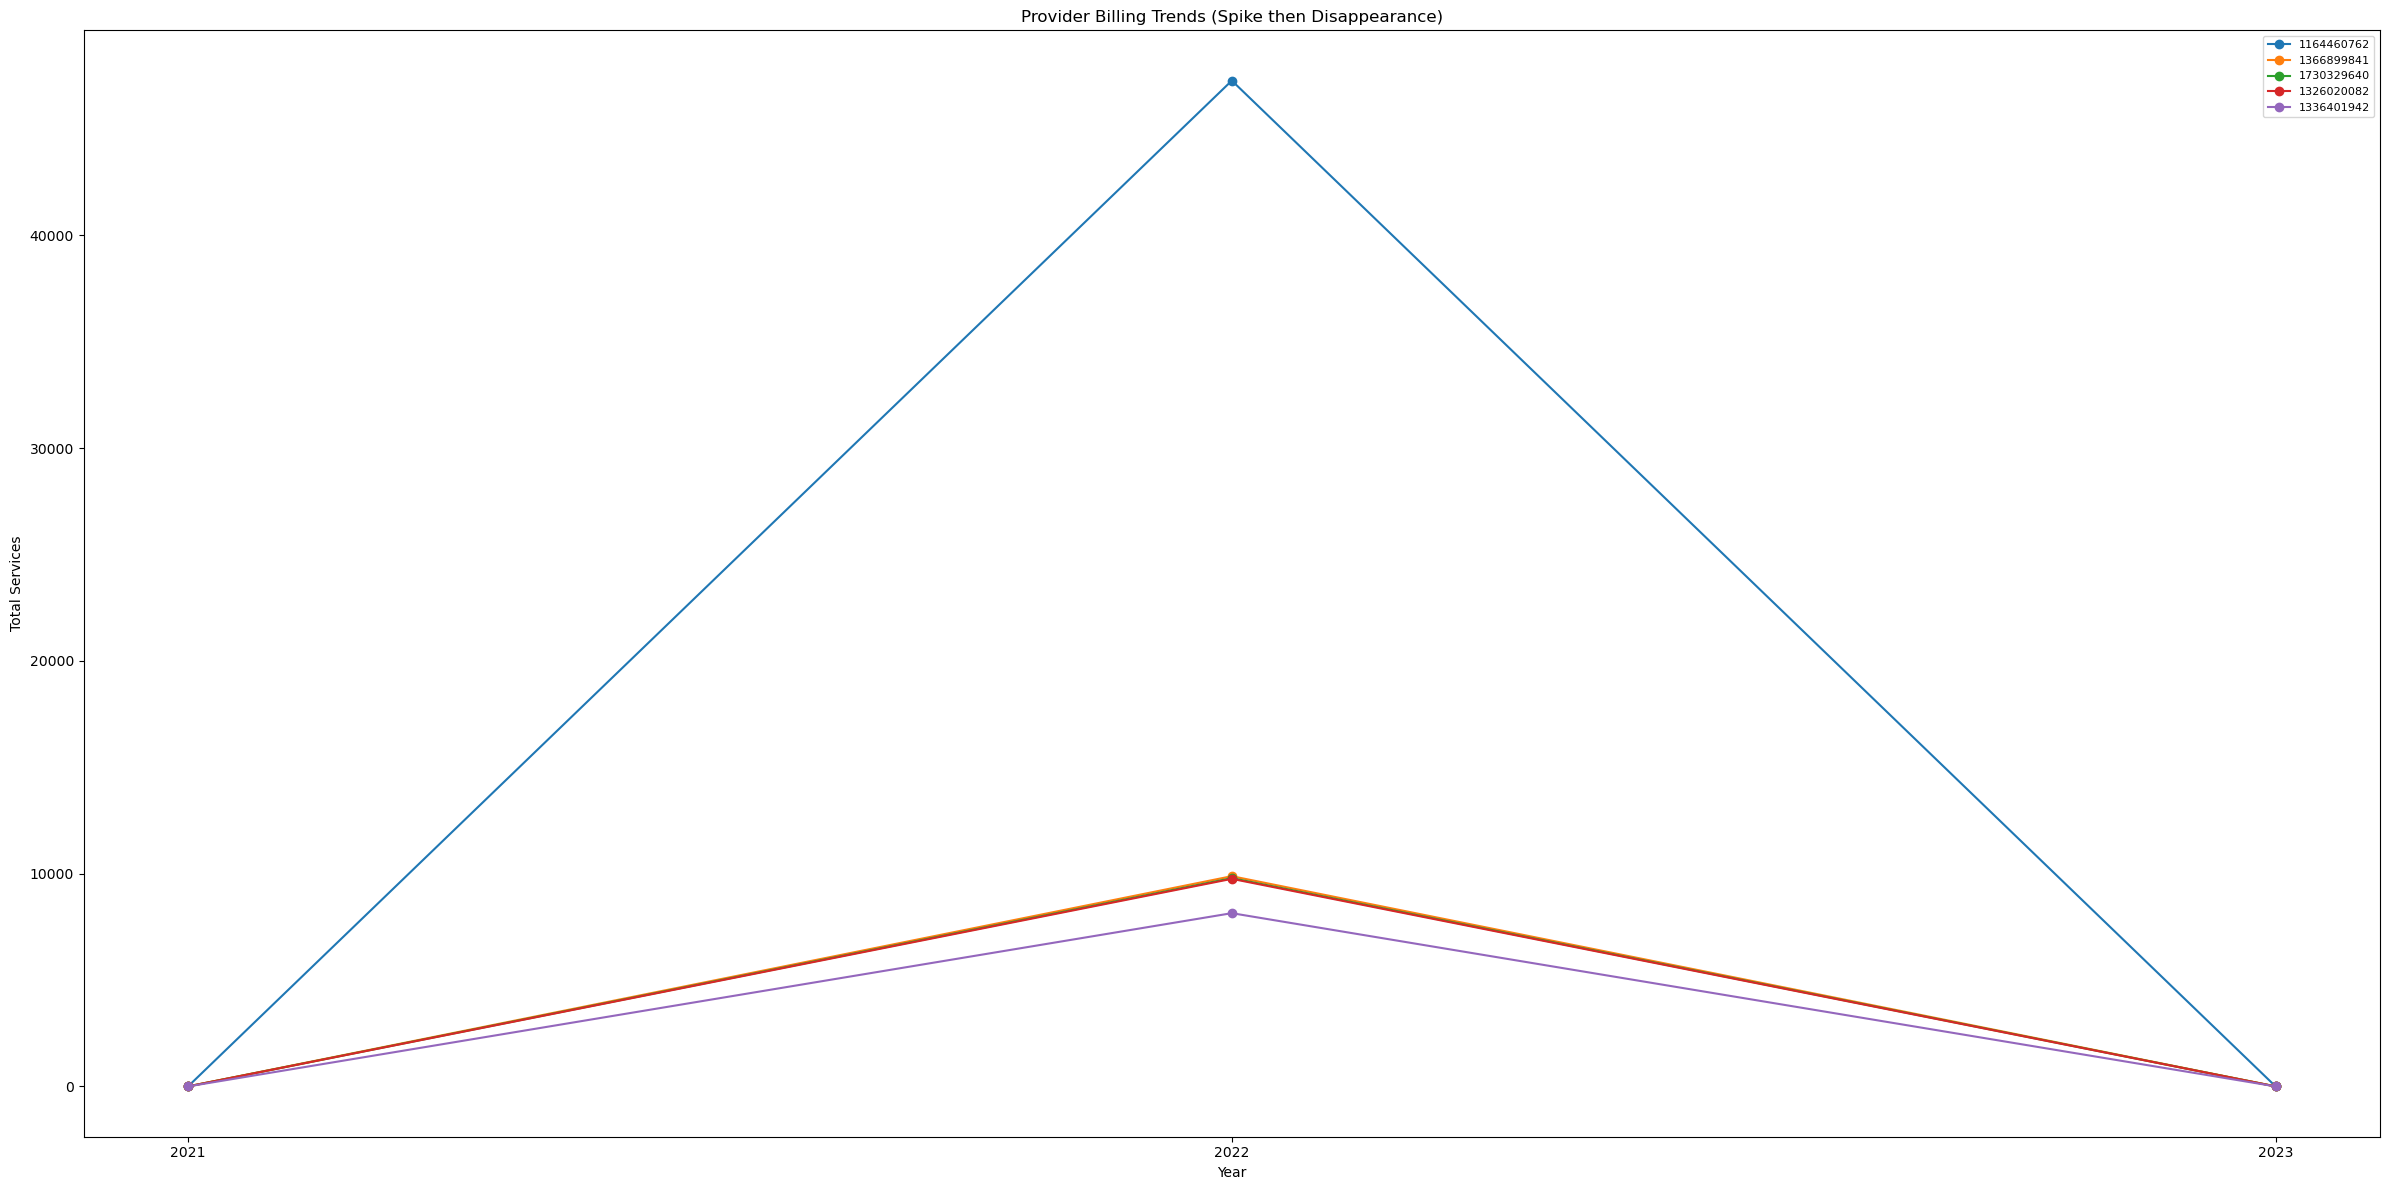

In [28]:
# Top providers used in the visualization
top_providers = fraud_pattern.head()

# NPIs for the line plot
top_npis = top_providers.index.tolist()

# Convert pivot table back to long format for line plot
trend_df = pivot.loc[top_npis].reset_index().melt(
    id_vars="npi",
    value_vars=[2021, 2022, 2023],
    var_name="year",
    value_name="tot_suplr_srvcs"
)

fig, axes = plt.subplots(1, figsize=(24, 12))

# -------------------------
# LINE PLOT (Supplier Trend)
# -------------------------
for npi in top_npis:

    data = trend_df[trend_df["npi"] == npi]

    axes.plot(
        data["year"],
        data["tot_suplr_srvcs"],
        marker="o",
        label=str(npi)
    )

axes.set_xticks([2021, 2022, 2023])
axes.set_title("Provider Billing Trends (Spike then Disappearance)")
axes.set_xlabel("Year")
axes.set_ylabel("Total Services")
axes.legend(fontsize=8)


plt.tight_layout()
plt.show()

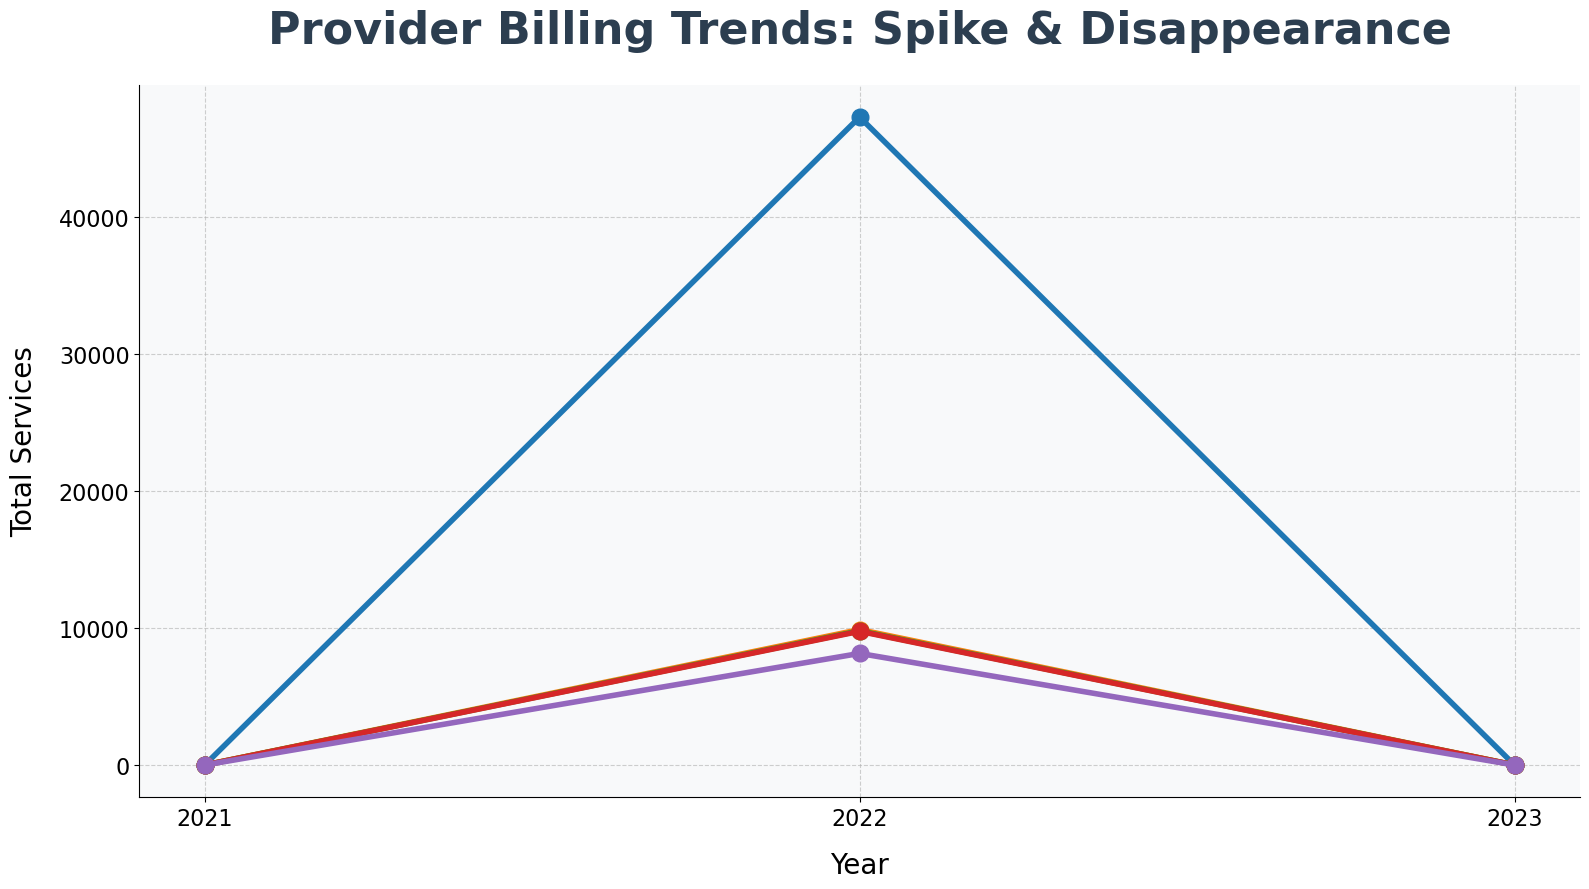

In [30]:
# Increase DPI for a crisp presentation image
fig, ax = plt.subplots(figsize=(16, 9), dpi=100)

# Set a clean background style
ax.set_facecolor('#f8f9fa')
ax.grid(True, linestyle='--', alpha=0.6, zorder=0)

for npi in top_npis:
    data = trend_df[trend_df["npi"] == npi]
    
    ax.plot(
        data["year"],
        data["tot_suplr_srvcs"],
        marker="o",
        markersize=12,    # Larger points
        linewidth=4,      # Thicker lines
        label=str(npi),
        zorder=3
    )

# --- VISUAL ENHANCEMENTS ---

# Huge Title for presentations
ax.set_title("Provider Billing Trends: Spike & Disappearance", 
             fontsize=32, pad=30, fontweight='bold', color='#2c3e50')

# Clearer Axis Labels
ax.set_xlabel("Year", fontsize=20, labelpad=15)
ax.set_ylabel("Total Services", fontsize=20, labelpad=15)

# Larger Tick Labels
ax.set_xticks([2021, 2022, 2023])
ax.tick_params(axis='both', labelsize=16)

# Legend refinement
# ax.legend(title="Supplier NPI", title_fontsize=16, fontsize=14, 
#           loc='upper right', frameon=True, shadow=True)

# Remove top/right spines for a modern look
for spine in ['top', 'right']:
    ax.spines[spine].set_visible(False)

plt.tight_layout()
plt.show()

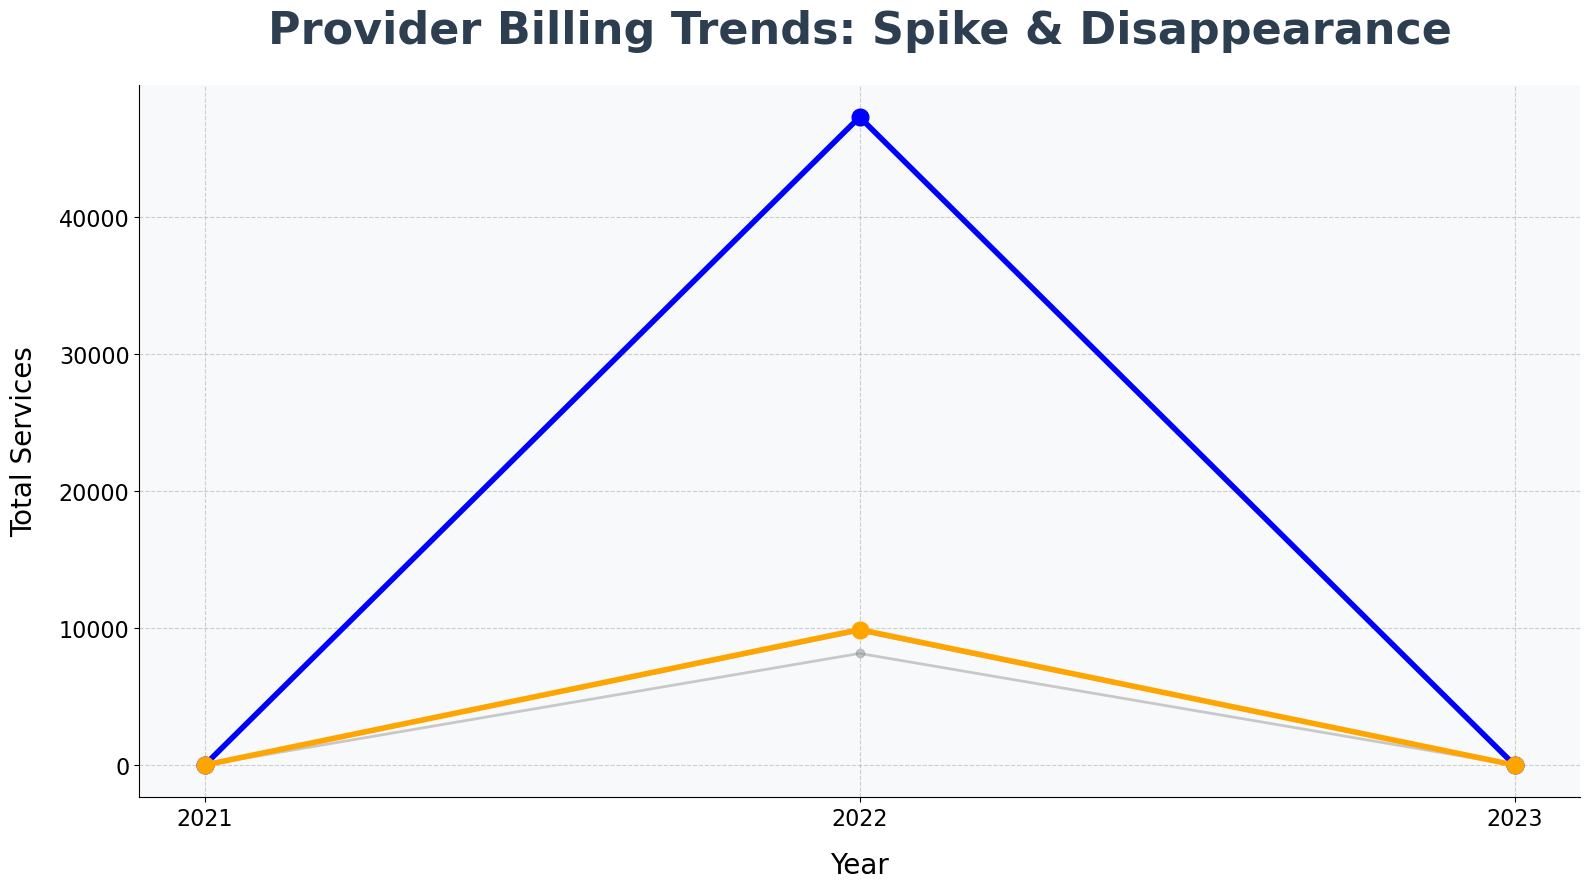

In [31]:
# Increase DPI for a crisp presentation image
fig, ax = plt.subplots(figsize=(16, 9), dpi=100)

# Set a clean background style
ax.set_facecolor('#f8f9fa')
ax.grid(True, linestyle='--', alpha=0.6, zorder=0)

# Define top 2 NPIs
top_2 = top_npis[:2]
others = top_npis[2:]

# --- Plot OTHER suppliers in grey (background) ---
for npi in others:
    data = trend_df[trend_df["npi"] == npi]
    
    ax.plot(
        data["year"],
        data["tot_suplr_srvcs"],
        color='grey',
        alpha=0.4,
        linewidth=2,
        marker='o',
        markersize=6,
        zorder=1
    )

# --- Plot TOP 2 suppliers in blue & orange (foreground) ---
colors = ['blue', 'orange']

for i, npi in enumerate(top_2):
    data = trend_df[trend_df["npi"] == npi]
    
    ax.plot(
        data["year"],
        data["tot_suplr_srvcs"],
        color=colors[i],
        marker="o",
        markersize=12,
        linewidth=4,
        label=f"Top {i+1}: {npi}",
        zorder=3
    )

# --- VISUAL ENHANCEMENTS ---

ax.set_title("Provider Billing Trends: Spike & Disappearance", 
             fontsize=32, pad=30, fontweight='bold', color='#2c3e50')

ax.set_xlabel("Year", fontsize=20, labelpad=15)
ax.set_ylabel("Total Services", fontsize=20, labelpad=15)

ax.set_xticks([2021, 2022, 2023])
ax.tick_params(axis='both', labelsize=16)

# # Legend ONLY for top 2
# ax.legend(title="Highlighted Suppliers", title_fontsize=16, fontsize=14,
#           loc='upper right', frameon=True, shadow=True)

# Remove top/right spines
for spine in ['top', 'right']:
    ax.spines[spine].set_visible(False)

plt.tight_layout()
plt.show()

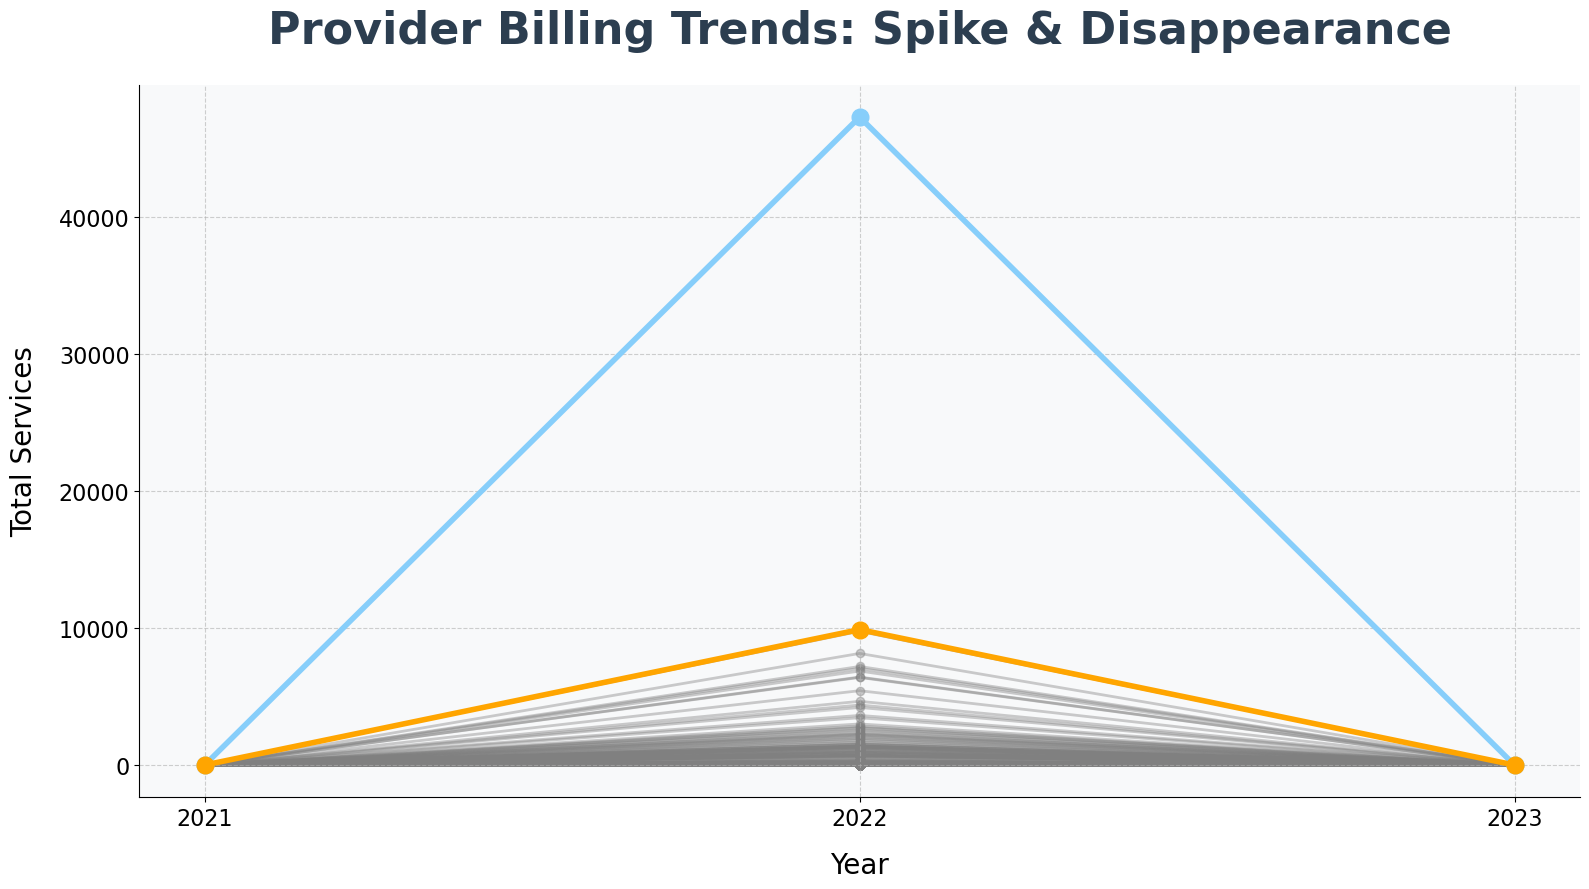

In [32]:
# NPIs for the line plot
all_npis = all_pattern.index.tolist()

# Convert pivot table back to long format for line plot
all_trend_df = pivot.loc[all_npis].reset_index().melt(
    id_vars="npi",
    value_vars=[2021, 2022, 2023],
    var_name="year",
    value_name="tot_suplr_srvcs"
)

# Increase DPI for a crisp presentation image
fig, ax = plt.subplots(figsize=(16, 9), dpi=100)

# Set a clean background style
ax.set_facecolor('#f8f9fa')
ax.grid(True, linestyle='--', alpha=0.6, zorder=0)

# Define top 2 NPIs
top_2 = all_npis[:2]
others = all_npis[2:]

# --- Plot OTHER suppliers in grey (background) ---
for npi in others:
    data = all_trend_df[all_trend_df["npi"] == npi]
    
    ax.plot(
        data["year"],
        data["tot_suplr_srvcs"],
        color='grey',
        alpha=0.4,
        linewidth=2,
        marker='o',
        markersize=6,
        zorder=1
    )

# --- Plot TOP 2 suppliers in blue & orange (foreground) ---
colors = ['#87CEFA', 'orange']

for i, npi in enumerate(top_2):
    data = trend_df[trend_df["npi"] == npi]
    
    ax.plot(
        data["year"],
        data["tot_suplr_srvcs"],
        color=colors[i],
        marker="o",
        markersize=12,
        linewidth=4,
        label=f"Top {i+1}: {npi}",
        zorder=3
    )

# --- VISUAL ENHANCEMENTS ---

ax.set_title("Provider Billing Trends: Spike & Disappearance", 
             fontsize=32, pad=30, fontweight='bold', color='#2c3e50')

ax.set_xlabel("Year", fontsize=20, labelpad=15)
ax.set_ylabel("Total Services", fontsize=20, labelpad=15)

ax.set_xticks([2021, 2022, 2023])
ax.tick_params(axis='both', labelsize=16)

# # Legend ONLY for top 2
# ax.legend(title="Highlighted Suppliers", title_fontsize=16, fontsize=14,
#           loc='upper right', frameon=True, shadow=True)

# Remove top/right spines
for spine in ['top', 'right']:
    ax.spines[spine].set_visible(False)

plt.tight_layout()
plt.show()

In [33]:
trend_df

,npi,year,tot_suplr_srvcs
0,1164460762,2021,0.0
1,1366899841,2021,0.0
2,1730329640,2021,0.0
3,1326020082,2021,0.0
4,1336401942,2021,0.0
5,1164460762,2022,47264.0
6,1366899841,2022,9880.0
7,1730329640,2022,9789.0
8,1326020082,2022,9755.0
9,1336401942,2022,8142.0


In [34]:
all_npis

[1164460762,
 1366899841,
 1730329640,
 1326020082,
 1336401942,
 1114683810,
 1154347375,
 1164490355,
 1992970792,
 1114968435,
 1346899671,
 1689651218,
 1346516556,
 1750311395,
 1801817226,
 1184240079,
 1225493844,
 1205414885,
 1356776181,
 1952749756,
 1023269701,
 1164185690,
 1164186540,
 1316393473,
 1114030202,
 1437718483,
 1235130345,
 1528067097,
 1902339104,
 1255644761,
 1811481955,
 1942242375,
 1093324816,
 1174667109,
 1548447113,
 1093981946,
 1881900058,
 1891172748,
 1588943880,
 1033735196,
 1639424211,
 1700831732,
 1578158325,
 1073531596,
 1518901545,
 1750546735,
 1194923151,
 1619588746,
 1013672104,
 1144527490,
 1912007055,
 1598262305,
 1912223298,
 1124387675,
 1164633111,
 1801318951,
 1306804489,
 1649633736,
 1306474713,
 1629092408,
 1578714895,
 1295929941,
 1265794432,
 1629269519,
 1922090125,
 1225088891,
 1215148168,
 1962715649,
 1689673675,
 1063893949,
 1386619138,
 1760757959,
 1710376165,
 1710353313,
 1518975283,
 1780016584,
 1205091485,

In [35]:
# -----------------------------------------
# EXPORT DATA FOR LINE PLOT (TREND)
# -----------------------------------------

# Use the top suppliers already identified
top_providers = fraud_pattern.sort_values(
    "growth_21_22", ascending=False
).head(5)

top_npis = top_providers.index.tolist()

# Convert pivot to long format
trend_export = pivot.loc[top_npis].reset_index().melt(
    id_vars="npi",
    value_vars=[2021, 2022, 2023],
    var_name="year",
    value_name="tot_suplr_srvcs"
)

trend_export.to_csv("provider_spike_trend.csv", index=False)

print("Saved: provider_spike_trend.csv")

Saved: provider_spike_trend.csv


In [36]:
trend_export

,npi,year,tot_suplr_srvcs
0,1164460762,2021,0.0
1,1366899841,2021,0.0
2,1730329640,2021,0.0
3,1326020082,2021,0.0
4,1336401942,2021,0.0
5,1164460762,2022,47264.0
6,1366899841,2022,9880.0
7,1730329640,2022,9789.0
8,1326020082,2022,9755.0
9,1336401942,2022,8142.0


In [38]:
# -----------------------------------------
# EXPORT HCPCS TABLE FOR SUPPLIERS
# -----------------------------------------

# Filter original dataset for those suppliers
provider_hcpcs_code = df_mo[df_mo["npi"].isin(top_npis)]

# Sum services by supplier and HCPCS code
provider_hcpcs_code = (
    provider_hcpcs_code
    .groupby(["npi","hcpcs_cd"])["tot_suplr_srvcs"]
    .sum()
    .reset_index()
)

# Pivot into table format
hcpcs_table = provider_hcpcs_code.pivot(
    index="npi",
    columns="hcpcs_cd",
    values="tot_suplr_srvcs"
).fillna(0)

# Keep only columns with activity
hcpcs_table = hcpcs_table.loc[:, (hcpcs_table.sum() > 0)]

hcpcs_table.to_csv("provider_hcpcs_table.csv")

print("Saved: provider_hcpcs_table.csv")

Saved: provider_hcpcs_table.csv


In [39]:
provider_hcpcs = provider_hcpcs.reset_index(drop=True)
provider_hcpcs

,npi,rfrg_prvdr_last_name_org,rfrg_prvdr_first_name,hcpcs_cd,hcpcs_desc,tot_suplr_srvcs
0,1164460762,Esguerra,Eden,A4221,"Supplies for maintenance of non-insulin drug infusion catheter, per week (list drugs separately)",14
1,1164460762,Esguerra,Eden,A4222,"Infusion supplies for external drug infusion pump, per cassette or bag (list drugs separately)",279
2,1164460762,Esguerra,Eden,J0133,"Injection, acyclovir, 5 mg",46971
3,1326020082,Byrne,Kevin,B4034,"Enteral feeding supply kit; syringe fed, per day, includes but not limited to feeding/flushing syringe, administration set tubing, dressings, tape",637
4,1326020082,Byrne,Kevin,B4152,"Enteral formula, nutritionally complete, calorically dense (equal to or greater than 1.5 kcal/ml) with intact nutrients, includes proteins, fats, carbohydrates, vitamins and minerals, may include fiber, administered through an enteral feeding tube, 100 calories = 1 unit",9118
5,1336401942,Patel,Mitesh,B4150,"Enteral formula, nutritionally complete with intact nutrients, includes proteins, fats, carbohydrates, vitamins and minerals, may include fiber, administered through an enteral feeding tube, 100 calories = 1 unit",8142
6,1366899841,Brenneman,Randall,B4036,"Enteral feeding supply kit; gravity fed, per day, includes but not limited to feeding/flushing syringe, administration set tubing, dressings, tape",396
7,1366899841,Brenneman,Randall,B4152,"Enteral formula, nutritionally complete, calorically dense (equal to or greater than 1.5 kcal/ml) with intact nutrients, includes proteins, fats, carbohydrates, vitamins and minerals, may include fiber, administered through an enteral feeding tube, 100 calories = 1 unit",9471
8,1366899841,Brenneman,Randall,E0776,Iv pole,13
9,1730329640,Ledl,Stephanie,B4034,"Enteral feeding supply kit; syringe fed, per day, includes but not limited to feeding/flushing syringe, administration set tubing, dressings, tape",310


In [40]:
provider_hcpcs.to_csv("provider_surges_products.csv")
print("Saved: provider_surges_products.csv")

Saved: provider_surges_products.csv


/opt/conda/lib/python3.11/site-packages/seaborn/_base.py:948: FutureWarning: When grouping with a length-1 list-like, you will need to pass a length-1 tuple to get_group in a future version of pandas. Pass `(name,)` instead of `name` to silence this warning.
  data_subset = grouped_data.get_group(pd_key)
/opt/conda/lib/python3.11/site-packages/seaborn/categorical.py:1273: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  .apply(aggregator, agg_var)
/opt/conda/lib/python3.11/site-packages/seaborn/_base.py:948: FutureWarning: When grouping with a length-1 list-like, you will need to pass a length-1 tuple to get_group in a future version of pandas. Pass `(name,)` instead of `name` to silence this warning.
  

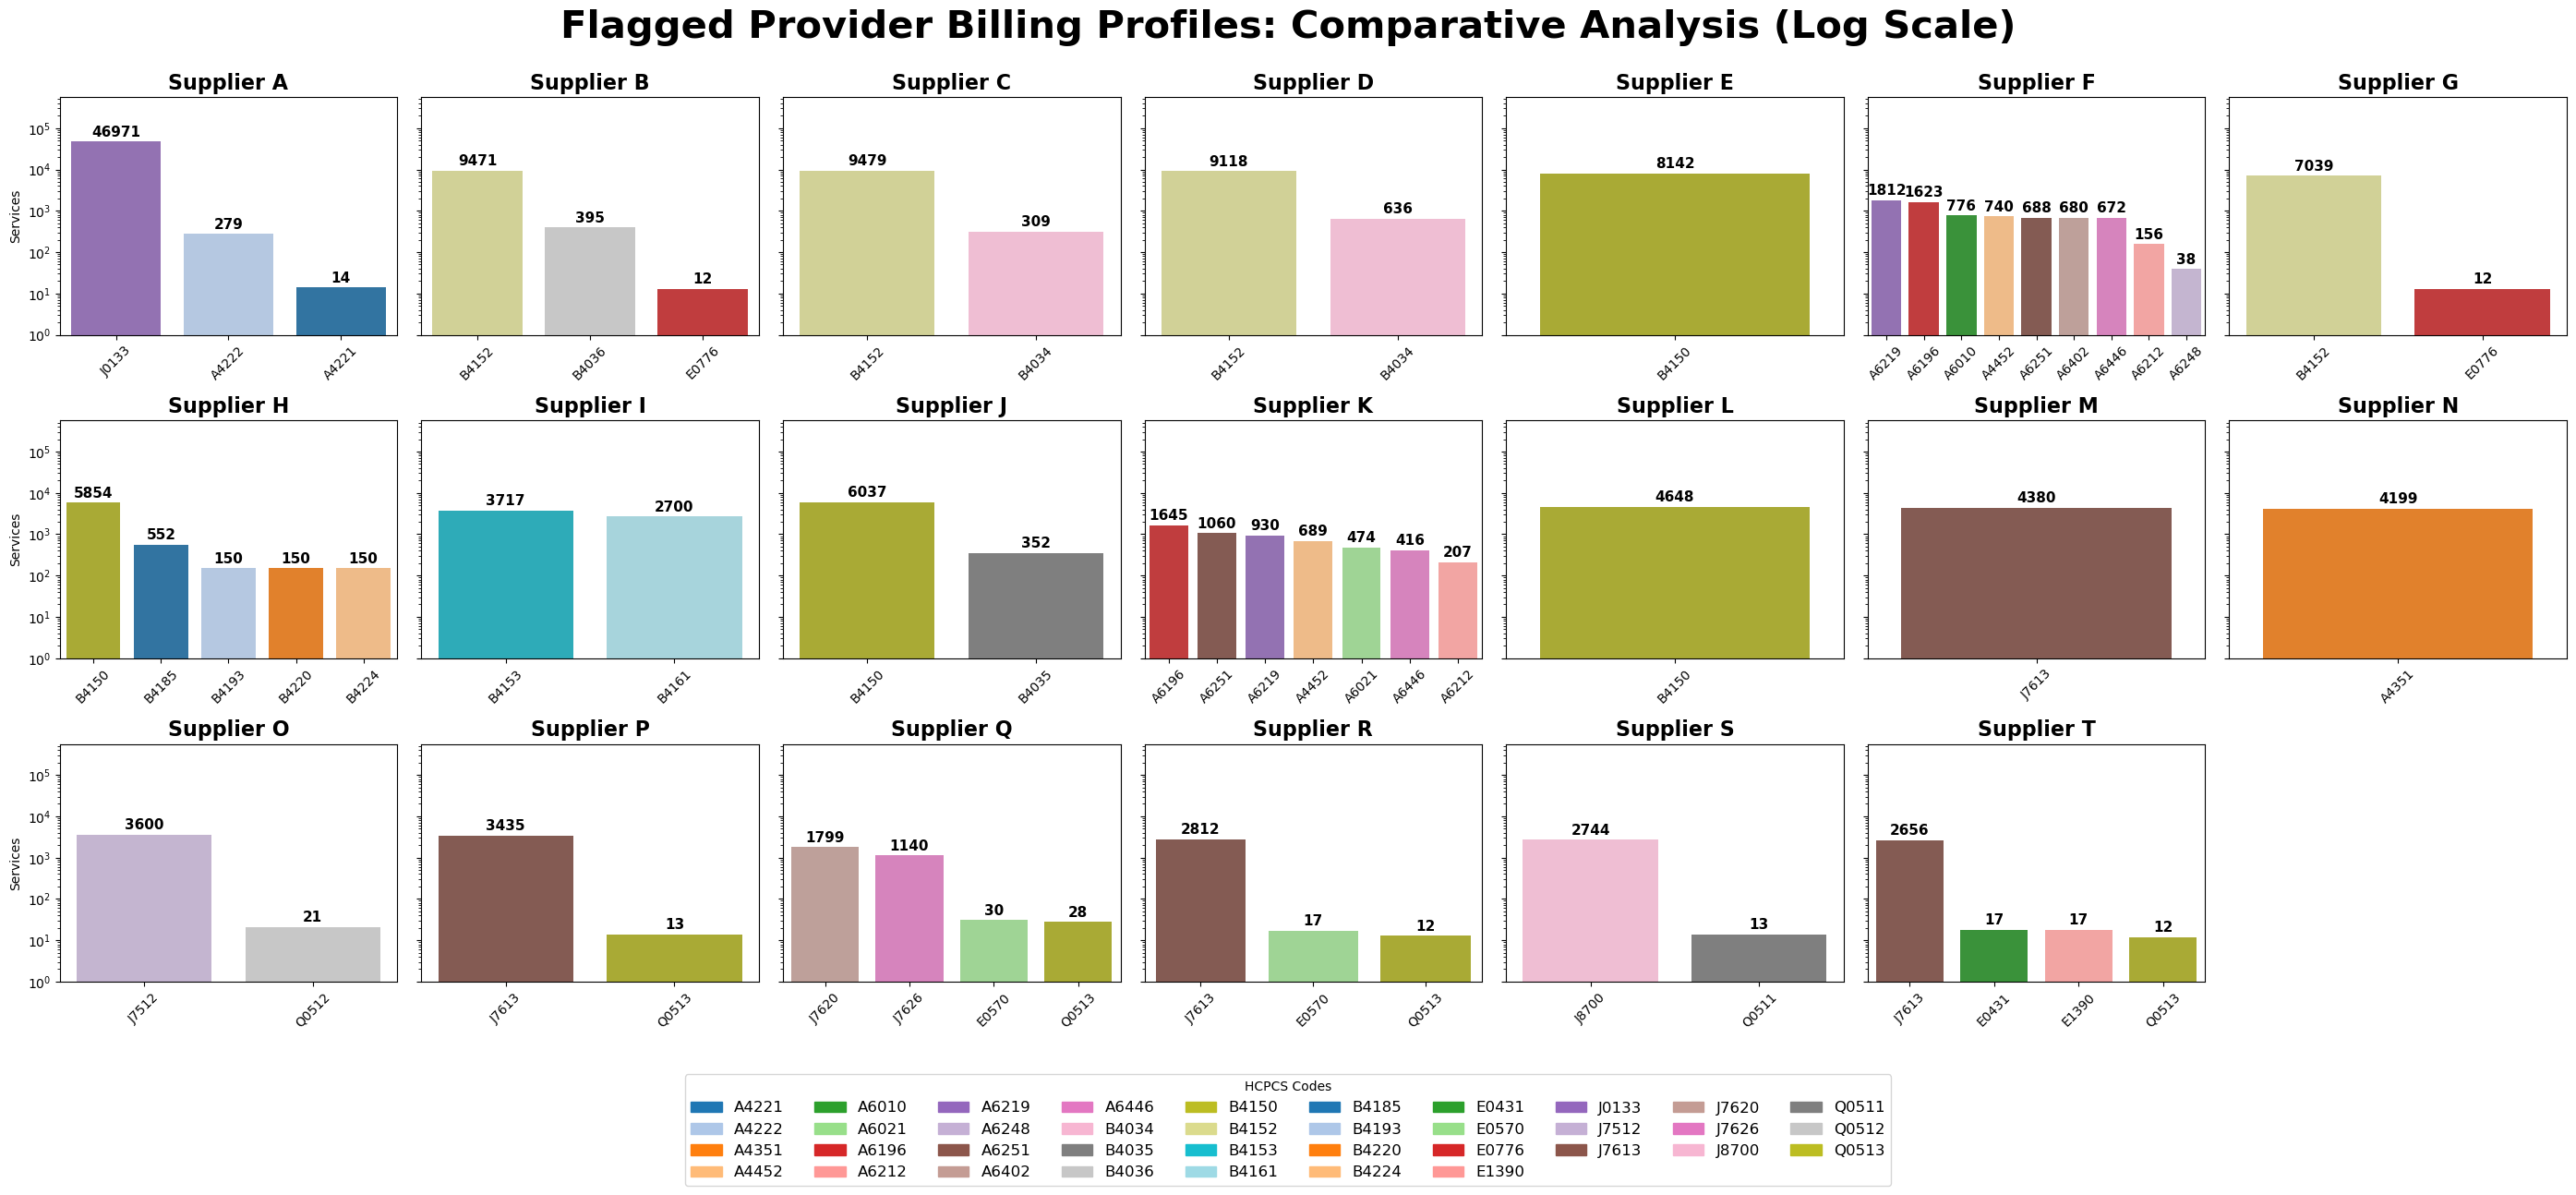

In [42]:
import seaborn as sns
import math
import string
import matplotlib.patches as mpatches

# 1. Setup Data & Colors
all_npis = all_pattern.head(20).index.tolist() # limit to a reasonable number
plot_data = df_mo[(df_mo["npi"].isin(all_npis)) & (df_mo["year"] == 2022) & (df_mo["tot_suplr_srvcs"] > 0)].copy()

unique_codes = sorted(plot_data['hcpcs_cd'].unique())
palette_colors = sns.color_palette("tab20", len(unique_codes))
code_color_map = dict(zip(unique_codes, palette_colors))

# 2. RECTANGULAR GRID SETUP
num_npis = len(all_npis)
cols = 7  # Increased columns for a landscape "Rectangle" shape
rows = math.ceil(num_npis / cols)

# Adjusting figsize: Wide (28) and relatively shorter height (4 per row)
fig, axes = plt.subplots(rows, cols, figsize=(28, 4.5 * rows), sharey=True) 
axes = axes.flatten()

# 3. LOOP
for i, npi in enumerate(all_npis):
    npi_specific_data = plot_data[plot_data["npi"] == npi].sort_values("tot_suplr_srvcs", ascending=False)
    
    if not npi_specific_data.empty:
        sns.barplot(
            data=npi_specific_data, 
            x="hcpcs_cd", y="tot_suplr_srvcs", 
            ax=axes[i], hue="hcpcs_cd",
            palette=code_color_map, dodge=False
        )
        
        # Manual legend removal for older Seaborn versions
        leg = axes[i].get_legend()
        if leg: leg.remove()
        
        axes[i].set_yscale('log')
        
        # Bar Labels
        for p in axes[i].patches:
            height = p.get_height()
            if height > 0:
                axes[i].text(p.get_x() + p.get_width() / 2., height * 1.15, 
                             f'{int(height)}', ha='center', va='bottom', 
                             fontsize=11, fontweight='bold') # Slightly smaller font for tighter grid
        
        # Titles
        supplier_label = string.ascii_uppercase[i] if i < 26 else f"Z{i-25}"
        axes[i].set_title(f"Supplier {supplier_label}", fontweight='bold', fontsize=16)
        
        # Cleanup
        axes[i].set_xlabel("") 
        axes[i].set_ylabel("Services")
        axes[i].tick_params(axis='x', rotation=45, labelsize=10)
        axes[i].set_ylim(1, plot_data["tot_suplr_srvcs"].max() * 12)
        
    else:
        axes[i].axis('off') 

# Remove extra empty subplots if any
for j in range(i + 1, len(axes)):
    axes[j].axis('off')

# 4. GLOBAL LEGEND
legend_handles = [mpatches.Patch(color=color, label=code) for code, color in code_color_map.items()]

fig.legend(
    handles=legend_handles,
    loc='lower center',
    bbox_to_anchor=(0.5, 0.03), 
    ncol=min(len(legend_handles), 10), # More columns in legend to match wide plot
    title="HCPCS Codes",
    fontsize=12,
    frameon=True
)

# 5. POLISH
# Higher 'rect' bottom value (0.15) to ensure the legend doesn't overlap the bottom row
plt.tight_layout(rect=[0, 0.15, 1, 0.94]) 

fig.suptitle('Flagged Provider Billing Profiles: Comparative Analysis (Log Scale)', 
             fontsize=30, y=0.98, fontweight='bold')

plt.show()

/opt/conda/lib/python3.11/site-packages/seaborn/_base.py:948: FutureWarning: When grouping with a length-1 list-like, you will need to pass a length-1 tuple to get_group in a future version of pandas. Pass `(name,)` instead of `name` to silence this warning.
  data_subset = grouped_data.get_group(pd_key)
/opt/conda/lib/python3.11/site-packages/seaborn/categorical.py:1273: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  .apply(aggregator, agg_var)
/opt/conda/lib/python3.11/site-packages/seaborn/_base.py:948: FutureWarning: When grouping with a length-1 list-like, you will need to pass a length-1 tuple to get_group in a future version of pandas. Pass `(name,)` instead of `name` to silence this warning.
  

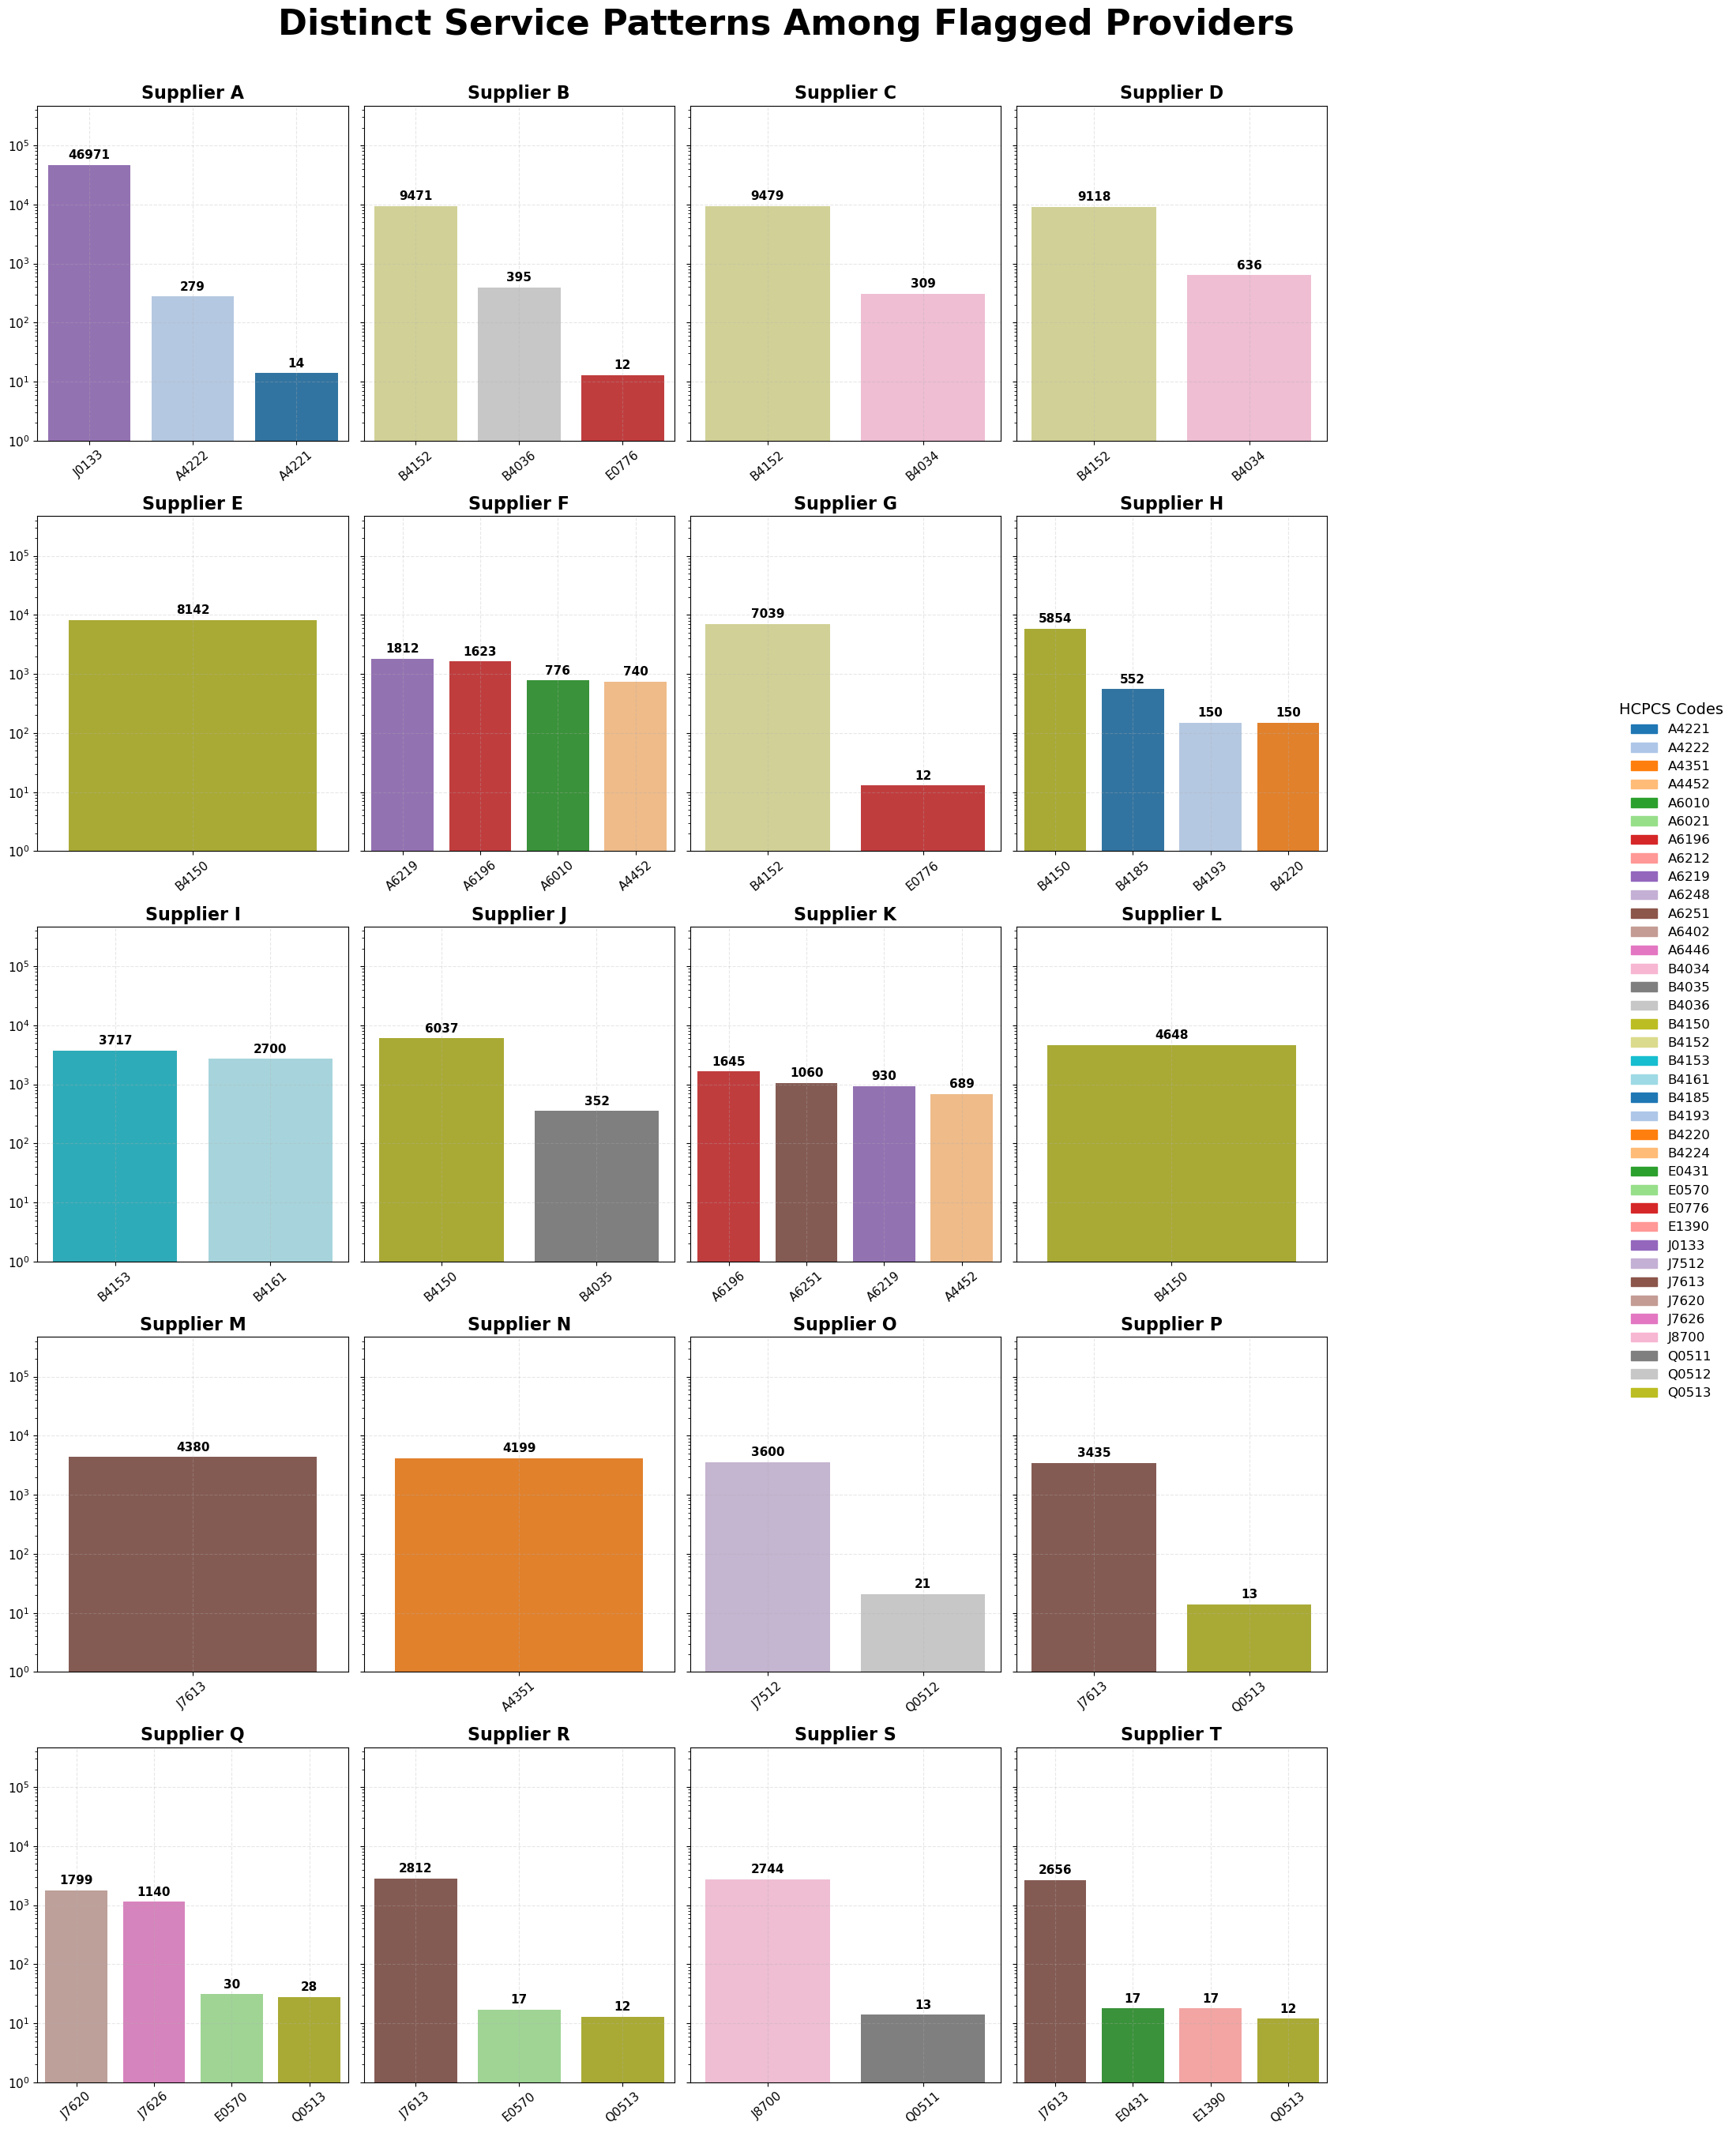

In [44]:
# ---------------------------
# DATA SETUP
# ---------------------------
all_npis = all_pattern.head(20).index.tolist()

plot_data = df_mo[
    (df_mo["npi"].isin(all_npis)) &
    (df_mo["year"] == 2022) &
    (df_mo["tot_suplr_srvcs"] > 0)
].copy()

# Color mapping
unique_codes = sorted(plot_data['hcpcs_cd'].unique())
palette_colors = sns.color_palette("tab20", len(unique_codes))
code_color_map = dict(zip(unique_codes, palette_colors))

# ---------------------------
# GRID (LESS COLUMNS = BIGGER CHARTS)
# ---------------------------
cols = 4   # 🔥 THIS FIXES READABILITY
rows = math.ceil(len(all_npis) / cols)

fig, axes = plt.subplots(
    rows, cols,
    figsize=(20, 5.5 * rows),   # taller plots
    sharey=True
)
axes = axes.flatten()

# ---------------------------
# LOOP
# ---------------------------
for i, npi in enumerate(all_npis):

    npi_data = plot_data[
        plot_data["npi"] == npi
    ].sort_values("tot_suplr_srvcs", ascending=False)

    if not npi_data.empty:

        # Limit bars (still important)
        npi_data = npi_data.head(4)

        sns.barplot(
            data=npi_data,
            x="hcpcs_cd",
            y="tot_suplr_srvcs",
            ax=axes[i],
            hue="hcpcs_cd",
            palette=code_color_map,
            dodge=False
        )

        # Remove subplot legends
        leg = axes[i].get_legend()
        if leg:
            leg.remove()

        # Log scale
        axes[i].set_yscale('log')

        # Labels on bars
        for p in axes[i].patches:
            height = p.get_height()
            if height > 10:
                axes[i].text(
                    p.get_x() + p.get_width() / 2.,
                    height * 1.15,
                    f'{int(height)}',
                    ha='center',
                    va='bottom',
                    fontsize=11,
                    fontweight='bold'
                )

        # Titles
        label = string.ascii_uppercase[i] if i < 26 else f"S{i}"
        axes[i].set_title(
            f"Supplier {label}",
            fontsize=16,
            fontweight='bold'
        )

        # 🔥 BIGGER AXIS TEXT
        axes[i].tick_params(axis='x', rotation=40, labelsize=11)
        axes[i].tick_params(axis='y', labelsize=11)

        axes[i].set_xlabel("")
        axes[i].set_ylabel("")

        axes[i].grid(True, linestyle='--', alpha=0.3)

        axes[i].set_ylim(1, plot_data["tot_suplr_srvcs"].max() * 10)

    else:
        axes[i].axis('off')

# Remove empty plots
for j in range(i + 1, len(axes)):
    axes[j].axis('off')

# ---------------------------
# 🔥 LEGEND ON THE RIGHT (VISIBLE!)
# ---------------------------
legend_handles = [
    mpatches.Patch(color=color, label=code)
    for code, color in code_color_map.items()
]

fig.legend(
    handles=legend_handles,
    loc='center left',
    bbox_to_anchor=(1.02, 0.5),  # right side
    title="HCPCS Codes",
    fontsize=12,
    title_fontsize=14,
    frameon=False
)

# ---------------------------
# FINAL POLISH
# ---------------------------
plt.tight_layout(rect=[0, 0, 0.85, 0.95])  # leave space for legend

fig.suptitle(
    "Distinct Service Patterns Among Flagged Providers",
    fontsize=32,
    fontweight='bold'
)
 # ---------------------------
# SAVE FIGURE (HIGH QUALITY)
# ---------------------------
plt.savefig(
    "provider_service_patterns.png",
    dpi=300,                # 🔥 high resolution for PPT
    bbox_inches='tight',    # removes extra whitespace
    facecolor='white'       # clean background
)

plt.show()

In [30]:
#To check the ones, that where saved, you checked the .csv files that where created